<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [25]:
#Importation de la librairie Pandas
import pandas as pd

In [26]:
#Importation de la librairie plotly express
import plotly.express as px  # type: ignore

In [27]:
import seaborn as sns

In [28]:
import matplotlib.pyplot as plt

In [29]:
import numpy as np

In [30]:
import scipy.stats as stats

In [31]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [ ]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp=pd.read_excel("erp.xlsx")
#importation du fichier liaison.xlsx
df_liaison=pd.read_excel("liaison.xlsx")

FileNotFoundError: [Errno 2] No such file or directory: 'erp.xlsx'

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))
#La nature des données dans chacune des colonnes
print(df_erp.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print("Nombre de valeurs présentes dans chacune des colones",df_erp.count)
#.infos

Le tableau comporte 6 colonne(s)
product_id          int64
onsale_web          int64
price             float64
stock_quantity      int64
stock_status       object
purchase_price    float64
dtype: object
Nombre de valeurs présentes dans chacune des colones <bound method DataFrame.count of      product_id  onsale_web  price  stock_quantity stock_status  \
0          3847           1   24.2              16      instock   
1          3849           1   34.3              10      instock   
2          3850           1   20.8               0   outofstock   
3          4032           1   14.1              26      instock   
4          4039           1   46.0               3      instock   
..          ...         ...    ...             ...          ...   
820        7203           0   45.0              30      instock   
821        7204           0   45.0               9      instock   
822        7247           1   54.8               6      instock   
823        7329           0   26.5       

In [ ]:
#Afficher les 5 premières lignes de la table
print(df_erp.head())

   product_id  onsale_web  price  stock_quantity stock_status  purchase_price
0        3847           1   24.2              16      instock           12.88
1        3849           1   34.3              10      instock           17.54
2        3850           1   20.8               0   outofstock           10.64
3        4032           1   14.1              26      instock            6.92
4        4039           1   46.0               3      instock           23.77


In [ ]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
verif_doublons=df_erp[df_erp['product_id'].duplicated()]
print(verif_doublons)

Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price]
Index: []


Ces valeurs sont liées à la colonne stock_quantity

In [ ]:
#Afficher les valeurs distinctes de la colonne stock_status
print(df_erp['stock_status'].unique())
#À quelle(s) autre(s) colonne(s) sont-elles liées ?



['instock' 'outofstock']


In [ ]:
#Création d'une colonne "stock_status_2
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"

df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if pd.isna(x) or x == 0 or x < 0 else 'instock')


In [ ]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]


0      True
1      True
2      True
3      True
4      True
       ... 
820    True
821    True
822    True
823    True
824    True
Length: 825, dtype: bool

In [ ]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3


#Afficher les deux colones
print(df_erp[df_erp['product_id'].isin([4039, 4885])])



     product_id  onsale_web  price  stock_quantity stock_status  \
4          4039           1   46.0               3      instock   
398        4885           1   18.7               0   outofstock   

     purchase_price stock_status_2  
4             23.77        instock  
398            9.66     outofstock  


 1 Problème detecté : pour le product_id 4039, on a 3 quantité en stock mais c'est marqué outofstock et également pour le product 4885, nous avons 0 quantité mais c'est reférencé instock

In [ ]:
#Corriger la ou les données incohérentes

#Verification en utilisant le même code que plus haut pour afficher les problemes


#Corriger a la main ces valeurs

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

On peut supprimer les champs et envoyer la nouvelle liste aux equipes


In [ ]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
#Afficher le ou les prix non renseignés dans la colonne "price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['price'].isna().sum()))

#Afficher le prix minimum de la colonne "price"
print("Le prix minimum :",df_erp['price'].min())
#Afficher le prix maximum de la colonne "price"
print("Le prix maximum : ",df_erp['price'].max())
#Affichier les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print(df_erp[df_erp['price'] < 0])

Nombres d'articles avec un prix non renseigné: 0
Le prix minimum : -20.0
Le prix maximum :  225.0
     product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

Les quantités négatives sont des valeurs aberrantes, on devrait les supprimer et informer les équipes de ces suppressions

In [ ]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
print("Quantité minimum de stock",df_erp['stock_quantity'].min())
#Afficher la quantité maximum de la colonne "stock_quantity"
print("Quantité maximum de stock",df_erp['stock_quantity'].max())
#Affichier les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print(df_erp[df_erp['stock_quantity'] < 0])

Quantité minimum de stock -10
Quantité maximum de stock 145
     product_id  onsale_web  price  stock_quantity stock_status  \
449        4973           0   10.0             -10   outofstock   
573        5700           1   44.5              -1   outofstock   

     purchase_price stock_status_2  
449            4.96     outofstock  
573           22.30     outofstock  


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

Les valeurs de onsale_web pourrait signifier --> 1 :" Article disponible sur internet "     0 : " Article pas disponible "

In [ ]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?
print(df_erp["onsale_web"].unique())

[1 0]


Les colonnes à conserver seraient : product_id, price, stock_quantity, purchase_price,onsale_web

In [ ]:
#Quelles sont les colonnes à conserver selon vous?


In [ ]:
#Supprimer la colonnecomportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".

df_erp.drop(columns=['stock_status_2', 'stock_status'], inplace=True)


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [ ]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
print("Nombres d'articles avec un prix non renseigné: {}".format(df_erp['purchase_price'].isna().sum()))
#Afficher le prix minimum de la colonne "purchase_price"
print("Le prix minimum de la colone purchase_price",df_erp['purchase_price'].min())
#Afficher le prix maximum de la colonne "purchase_price"
print("Le prix maximum de la colone purchase_price",df_erp['purchase_price'].max())

Nombres d'articles avec un prix non renseigné: 0
Le prix minimum de la colone purchase_price 2.74
Le prix maximum de la colone purchase_price 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [ ]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))
#Nombre de caractéristiques


Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

Colonnes à conserver : sku<br>
total_sales<br>
post_title<br>
post_excerpt<br>
product_type

In [ ]:
#Selon vous, quelles sont les colonnes à conserver ?


In [ ]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération

df_web = df_web.drop(columns=['tax_status', 'tax_class', 'post_content', 'post_password', 'post_content_filtered'])




Valeurs qui semblent ne pas respecter : 13127-1 bon-cadeau-25-euros
et nan



In [ ]:
#Visualisation des valeurs de la colonne sku
print(df_web['sku'])

#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?


0       11862
1       16057
2       14692
3       16295
4       15328
        ...  
1508    16326
1509    15662
1510    15329
1511    14827
1512    16004
Name: sku, Length: 1513, dtype: object


In [ ]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
print(df_web[df_web['sku'].isin(['13127-1','bon-cadeau-25-euros'])])


                      sku  virtual  downloadable  rating_count  \
272               13127-1        0             0             0   
842   bon-cadeau-25-euros        0             0             0   
1117              13127-1        0             0             0   
1387  bon-cadeau-25-euros        0             0             0   

      average_rating  total_sales  post_author           post_date  \
272              0.0          4.0          2.0 2020-06-09 15:42:04   
842              0.0          7.0          1.0 2018-06-01 13:53:46   
1117             0.0          4.0          2.0 2020-06-09 15:42:04   
1387             0.0          7.0          1.0 2018-06-01 13:53:46   

           post_date_gmt product_type  ... ping_status  \
272  2020-06-09 13:42:04          Vin  ...      closed   
842  2018-06-01 11:53:46        Autre  ...      closed   
1117 2020-06-09 13:42:04          Vin  ...      closed   
1387 2018-06-01 11:53:46          NaN  ...      closed   

                           

In [ ]:
#Identifier les lignes sans code articles
df_sans_code_article = df_web[df_web['sku'].apply(lambda x: pd.isnull(x))]

print(df_sans_code_article[df_sans_code_article['sku'].isnull()])
# Afficher les champs qui sont non null par exemple utiliser un autre champ

      sku  virtual  downloadable  rating_count  average_rating  total_sales  \
8     NaN        0             0             0             NaN          NaN   
20    NaN        0             0             0             NaN          NaN   
30    NaN        0             0             0             NaN          NaN   
37    NaN        0             0             0             NaN          NaN   
41    NaN        0             0             0             NaN          NaN   
...   ...      ...           ...           ...             ...          ...   
1384  NaN        0             0             0             NaN          NaN   
1429  NaN        0             0             0             NaN          NaN   
1432  NaN        0             0             0             NaN          NaN   
1445  NaN        0             0             0             NaN          NaN   
1457  NaN        0             0             0             NaN          NaN   

      post_author post_date post_date_gmt product_t


On doit creer des sku fictifs car ces articles ont des champs bien définis par exemple sku_null1 et sku_null2





In [ ]:
df_sans_code_article = df_web[
    df_web['sku'].isnull() & df_web['total_sales'].notnull() & (df_web['total_sales'] != 0)
]
print(df_sans_code_article)

      sku  virtual  downloadable  rating_count  average_rating  total_sales  \
1084  NaN        0             0             0             0.0        -56.0   
1087  NaN        0             0             0             0.0        -17.0   

      post_author           post_date       post_date_gmt product_type  ...  \
1084          2.0 2018-08-08 11:23:43 2018-08-08 09:23:43          Vin  ...   
1087          2.0 2018-07-31 12:07:23 2018-07-31 10:07:23          Vin  ...   

     ping_status                                   post_name  \
1084      closed    pierre-jean-villa-condrieu-suspendu-2018   
1087      closed  pierre-jean-villa-cote-rotie-fongeant-2017   

           post_modified   post_modified_gmt post_parent  \
1084 2019-11-02 13:24:01 2019-11-02 12:24:01         0.0   
1087 2019-11-02 13:24:15 2019-11-02 12:24:15         0.0   

                                                   guid menu_order post_type  \
1084  https://www.bottle-neck.fr/?post_type=product&...        0.0   p

In [ ]:
#Supprimer les lignes ou le sku est vraiment vide
df_web = df_web.dropna(subset=['sku', 'product_type'], how='all')

print(df_web['sku'])

0       11862
1       16057
2       14692
3       16295
4       15328
        ...  
1508    16326
1509    15662
1510    15329
1511    14827
1512    16004
Name: sku, Length: 1430, dtype: object


Je constate que j'ai 2 lignes avec sku Nan mais  sont renseignées sur presque tous les autres champs

Je peux leur donner des  sku fictifs comme : sku_null1 et sku_null2

In [ ]:
df_web = df_web[df_web["post_type"] == "product"]
df_web.loc[1084, 'sku'] = 'sku_null1'
df_web.loc[1087, 'sku'] = 'sku_null2'

In [ ]:
#La clé pour chaque ligne est-elle uniques? ou autrement dit, y a-t-il des doublons?
print(df_web['sku'].size)
print(df_web['sku'].unique().size)


716
716


In [ ]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
#print(df_sans_code_article)
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur reseigner dans chacune des colonnes
df_web.info()
#3 - Que constatez-vous?

<class 'pandas.core.frame.DataFrame'>
Index: 716 entries, 2 to 1509
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   sku                716 non-null    object        
 1   virtual            716 non-null    int64         
 2   downloadable       716 non-null    int64         
 3   rating_count       716 non-null    int64         
 4   average_rating     716 non-null    float64       
 5   total_sales        716 non-null    float64       
 6   post_author        716 non-null    float64       
 7   post_date          716 non-null    datetime64[ns]
 8   post_date_gmt      716 non-null    datetime64[ns]
 9   product_type       715 non-null    object        
 10  post_title         716 non-null    object        
 11  post_excerpt       716 non-null    object        
 12  post_status        716 non-null    object        
 13  comment_status     716 non-null    object        
 14  ping_status   

In [ ]:
df_web_nettoyé=df_web[['sku','total_sales','post_title','post_excerpt','product_type']]
print(df_web_nettoyé['sku'].unique().size)


716


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [ ]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))
#Nombre de caractéristiques


Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


Oui elles sont uniques

In [ ]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
print(df_liaison['product_id'].size)
print(df_liaison['product_id'].unique().size)

825
825


Non, il y'a des doublons

In [ ]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
print(df_liaison['id_web'].size)
print(df_liaison['id_web'].unique().size)

825
735


Oui on a des articles sans correspondance

In [ ]:
#Avons-nous des articles sans correspondances?
df_filtré = df_liaison[df_liaison['id_web'].isnull() & df_liaison['product_id'].notnull()]
print(df_filtré)


    id_web  product_id
19     NaN        4055
49     NaN        4090
50     NaN        4092
119    NaN        4195
131    NaN        4209
..     ...         ...
817    NaN        7196
818    NaN        7200
819    NaN        7201
820    NaN        7203
821    NaN        7204

[91 rows x 2 columns]


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [ ]:
#Fusion des fichiers df_erp et df_liaison
Fusion_erp_liaison=pd.merge(df_erp,df_liaison,on='product_id',how='outer',indicator=True)
print(Fusion_erp_liaison)
#Mettre indicator pour confirmer si les lignes matchent ou pas

     product_id  onsale_web  price  stock_quantity  purchase_price   id_web  \
0          3847           1   24.2              16           12.88    15298   
1          3849           1   34.3              10           17.54    15296   
2          3850           1   20.8               0           10.64    15300   
3          4032           1   14.1              26            6.92    19814   
4          4039           1   46.0               3           23.77    19815   
..          ...         ...    ...             ...             ...      ...   
820        7203           0   45.0              30           23.48      NaN   
821        7204           0   45.0               9           24.18      NaN   
822        7247           1   54.8               6           27.18  13127-1   
823        7329           0   26.5              14           13.42  14680-1   
824        7338           1   16.3              40            8.00    16230   

    _merge  
0     both  
1     both  
2     both  

Chaque ligne du fichier liaison a bien une correspondance avec chaque ligne du fichier erp

In [ ]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [ ]:
df_web_nettoyé = df_web_nettoyé.drop_duplicates(subset='sku')
print(len(df_web_nettoyé))  



716


In [ ]:





# Fusionner les DataFrames
Fusion_erp_liaison_web = pd.merge(Fusion_erp_liaison, df_web_nettoyé, left_on='id_web', right_on='sku',how="outer")
# Afficher le résultat
print(Fusion_erp_liaison_web)


     product_id  onsale_web  price  stock_quantity  purchase_price id_web  \
0        4729.0         1.0    8.6            26.0            4.22     38   
1        4634.0         1.0   41.0            11.0           20.12     41   
2        4141.0         1.0   39.0           123.0           24.86    304   
3        5932.0         1.0   59.9            13.0           27.18    523   
4        5047.0         1.0   22.5            76.0           13.78    531   
..          ...         ...    ...             ...             ...    ...   
822      7196.0         0.0   31.0            55.0           31.20    NaN   
823      7200.0         0.0   31.0             6.0           15.54    NaN   
824      7201.0         0.0   31.0            18.0           16.02    NaN   
825      7203.0         0.0   45.0            30.0           23.48    NaN   
826      7204.0         0.0   45.0             9.0           24.18    NaN   

    _merge  sku  total_sales  \
0     both   38         10.0   
1     both 

Non

In [ ]:
#Avons-nous des lignes sans correspondances?


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

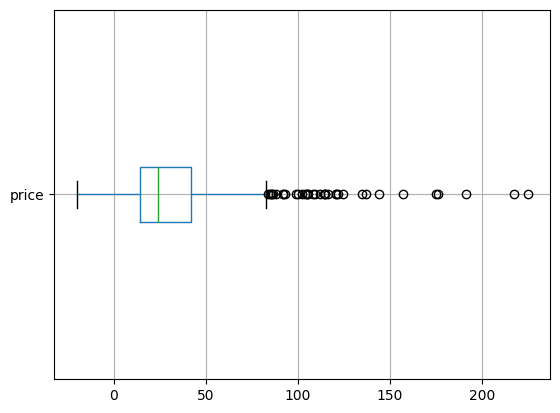

In [ ]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas
df_erp.boxplot(column='price',vert=False)

In [ ]:
#Autre méthode avec plotly express
px.box(df_erp,x='price')

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

Le z_score permet d'indiquer combien un point de donnée s'ecarte de la moyenne en terme d'ecart type

In [ ]:
#Calculer la moyenne du prix
moyenne_prix=df_erp['price'].mean()
print("moyenne : ",moyenne_prix)
#Calculer l'écart-type du prix
ecart_type_prix=df_erp['price'].std()
print("Ecart type : ",ecart_type_prix)
#Faire la moyenne divisé sur ecart type et passer en valeur absolue
#Calculer le Z-score

z_score1=abs(moyenne_prix/ecart_type_prix)
print(z_score1)


moyenne :  32.187696969696965
Ecart type :  26.712076775505277
1.204986689736261


In [ ]:
#Quel est le seuil prix dont z-score est supérieur à 3?
df_zscore = (df_erp['price'] - df_erp['price'].mean()) / df_erp['price'].std()

df_outliers = df_erp[df_zscore > 3]


seuil_prix = df_outliers['price'].min()

print("Seuil du prix avec Z-score > 3:", seuil_prix)


Seuil du prix avec Z-score > 3: 114.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [ ]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
print(df_erp['price'].describe())

count    825.000000
mean      32.187697
std       26.712077
min      -20.000000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64


Seuil : 120€

In [ ]:
#Définissez un seuil pour les articles "outliers" en prix
Q1=df_erp['price'].quantile(0.25)
Q3=df_erp['price'].quantile(0.75)
IQR=Q3-Q1
borne_sup=Q3 +1.5*IQR
borne_inf=Q3 - 1.5*IQR
print(borne_sup)

83.25


In [ ]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"

df_outliers = df_erp[df_erp['price'] >= borne_sup ]

nbre_article=len(df_erp)
nbre_outliers=len(df_outliers)
print(nbre_outliers)
proportion_outliers =(nbre_outliers/nbre_article)*100
print(proportion_outliers)

36
4.363636363636364


Oui ces outliser sont justifiés

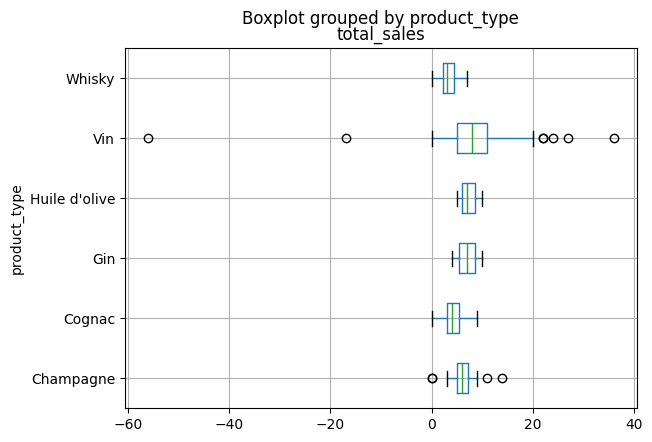

In [ ]:
df_web.boxplot(column='total_sales', by='product_type', vert=False)
plt.show()

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [ ]:
##############################
# Calculer le CA su site web #
##############################
# Afficher le DataFrame (facultatif pour vérification)




Fusion_erp_liaison_web['ca_par_article'] = Fusion_erp_liaison_web['price'] * Fusion_erp_liaison_web['total_sales']
print(Fusion_erp_liaison_web)

ca_total = Fusion_erp_liaison_web['ca_par_article'].sum()


print("Le chiffre d'affaire du site web est de {} euros".format(ca_total))


     product_id  onsale_web  price  stock_quantity  purchase_price id_web  \
0        4729.0         1.0    8.6            26.0            4.22     38   
1        4634.0         1.0   41.0            11.0           20.12     41   
2        4141.0         1.0   39.0           123.0           24.86    304   
3        5932.0         1.0   59.9            13.0           27.18    523   
4        5047.0         1.0   22.5            76.0           13.78    531   
..          ...         ...    ...             ...             ...    ...   
822      7196.0         0.0   31.0            55.0           31.20    NaN   
823      7200.0         0.0   31.0             6.0           15.54    NaN   
824      7201.0         0.0   31.0            18.0           16.02    NaN   
825      7203.0         0.0   45.0            30.0           23.48    NaN   
826      7204.0         0.0   45.0             9.0           24.18    NaN   

    _merge  sku  total_sales  \
0     both   38         10.0   
1     both 

In [ ]:
###############################
# Palmares des articles en CA #
###############################

# Trier dans l'ordre décroissant et réinitialiser l'index
Fusion_trié = Fusion_erp_liaison_web.sort_values(by='ca_par_article', ascending=False).reset_index(drop=True)

# Graphique en barres horizontales
fig = px.bar(
    Fusion_trié.head(20),
    y='post_title',
    x='ca_par_article',
    title='Top 20 articles par chiffre d’affaires',
    labels={'ca_par_article': 'Chiffre d’affaires', 'post_title': 'Article'},
    text='ca_par_article',
    orientation='h'  # Horizontal
)

# Inverser l'ordre des y pour que la plus grande valeur soit en haut
fig.update_yaxes(autorange='reversed')

fig.show()


In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
Fusion_trié['part_ca']=Fusion_trié['ca_par_article']/Fusion_trié['ca_par_article'].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
Fusion_trié['somme_cumulative']=Fusion_trié['part_ca'].cumsum()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nb_article_80 = Fusion_trié[Fusion_trié['somme_cumulative'] <= 0.8]
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
nb_articles_80 = len(nb_article_80)
total_articles = len(Fusion_erp_liaison_web)
part_articles_80 = nb_articles_80 / total_articles
#Etre autour des 50%
print("Nombre d'articles qui représente  80% du CA : ",nb_articles_80)
print(f"Par rapport au catalogue entier, ça correspond à : {part_articles_80:.2%}")

Nombre d'articles qui représente  80% du CA :  434
Par rapport au catalogue entier, ça correspond à : 52.48%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

In [ ]:
#####################################
# Palmares des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
Fusion_trié_quantité = Fusion_erp_liaison_web.sort_values(by='total_sales', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
Fusion_trié_quantité.reset_index()
#Afficher les 20 premier articles en quantité
Fusion_trié_quantité.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
fig = px.bar(
    Fusion_trié_quantité.head(20),
    y='post_title',         # ou 'sku' si les titres sont longs
    x='total_sales',
    title='Top 20 articles les plus vendus (en quantité)',
    labels={'total_sales': 'Quantité vendue', 'post_title': 'Article'},
    text='total_sales',
    orientation='h'
)

fig.update_layout(xaxis_tickangle=45)
fig.update_yaxes(autorange='reversed')
fig.show()

# A voir dans le bon sens 

In [ ]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
Fusion_trié_quantité['part_ca']=Fusion_trié_quantité['total_sales'] / Fusion_trié_quantité['total_sales'].sum()
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
Fusion_trié_quantité['somme_cumulative']=Fusion_trié_quantité['part_ca'].cumsum()
#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_article_quantité_80 = Fusion_trié_quantité[Fusion_trié_quantité['somme_cumulative'] <= 0.8]
#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
nb_articles_quantité_80 = len(nb_article_quantité_80)
total_articles_quantité = len(Fusion_trié_quantité)
part_articles_quantité_80 = nb_articles_quantité_80 / total_articles_quantité

print("Nombre d'articles qui représente  80% du CA : ",nb_articles_quantité_80)
print(f"Par rapport au catalogue entier, ça correspond à : {part_articles_quantité_80:.2%}")

Nombre d'articles qui représente  80% du CA :  424
Par rapport au catalogue entier, ça correspond à : 51.27%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

La rotation de stock est un indicateur qui permet de mesurer la rapidité avec laquelle un stock est vendu

In [ ]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy 

#Création de la colonne Rotation de stock
Fusion_trié_quantité['rotation_stock'] =Fusion_erp_liaison_web['stock_quantity'] /Fusion_erp_liaison_web['total_sales']

#Remplacement des "inf" par 0
Fusion_trié_quantité.replace([np.inf, -np.inf], 0, inplace=True)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
Nbre_de_mois=Fusion_trié_quantité.sort_values(by='rotation_stock', ascending=False)
print(Nbre_de_mois.head(20)[['post_title', 'stock_quantity', 'total_sales', 'rotation_stock']])
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock 
fig = px.bar(
    Nbre_de_mois.head(20),
    y='post_title',
    x='rotation_stock',
    title='Flop 20 des produits avec la plus haute rotation de stock',
    labels={'rotation_stock': 'Mois de stock estimé', 'post_title': 'Produit'},
    text='rotation_stock'
)
fig.update_yaxes(autorange='reversed')
fig.show()

                                            post_title  stock_quantity  \
55               Champagne Gosset Grand Millésime 2006           125.0   
257             Champagne Gosset Célébris Vintage 2007           138.0   
75   Champagne Egly-Ouriet Premier Cru Les Vignes d...            81.0   
76      Champagne Egly-Ouriet Grand Cru Brut Tradition           125.0   
14                Champagne Mailly Grand Cru Brut Rosé            71.0   
38               Champagne Larmandier-Bernier Latitude           115.0   
16                         Champagne Gosset Grand Rosé            91.0   
150  Champagne Agrapart &amp; Fils L'Avizoise Extra...           136.0   
78     Champagne Egly-Ouriet Grand Cru Extra Brut V.P.           145.0   
15        Champagne Mailly Grand Cru Intemporelle 2010           123.0   
32              Champagne Gosset Grand Blanc de Blancs           142.0   
31   Champagne Mailly Grand Cru Intemporelle Rosé 2009           101.0   
256  Domaine Weinbach Gewurztraminer G

In [ ]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
Fusion_erp_liaison_web['valorisation_stock_euros'] = Fusion_erp_liaison_web['stock_quantity'] * Fusion_erp_liaison_web['purchase_price']
#Calculer la somme de la colonne "Valorisation_stock_euros"
total_Fusion=Fusion_erp_liaison_web['valorisation_stock_euros'] .sum()
print(total_Fusion)

298555.76


In [ ]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################


#Calculer la somme de la colonne stock quantity
total_produit_quantité=Fusion_erp_liaison_web['stock_quantity'].sum()
print(total_produit_quantité)

17811.0


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [ ]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
Fusion_erp_liaison_web['prix_ht'] = Fusion_erp_liaison_web['price'] / 1.2
Fusion_erp_liaison_web['purchase_price_ht'] = Fusion_erp_liaison_web['purchase_price'] / 1.2
#Création de la colonne Taux de marge
Fusion_erp_liaison_web['taux_marge'] = (Fusion_erp_liaison_web['prix_ht'] - Fusion_erp_liaison_web['purchase_price_ht']) / Fusion_erp_liaison_web['purchase_price_ht']

#Afficher le prix minimum de la colonne "taux_marge"
print("Le minimum est :",Fusion_erp_liaison_web['taux_marge'].min(),"%")
#Afficher le prix maximum de la colonne "taux_marge"
print("Le maximum est :",Fusion_erp_liaison_web['taux_marge'].max(),"%")

Le minimum est : -2.973969631236442 %
Le maximum est : 1.296949650863653 %


In [ ]:
#affichage de la ligne avec un taux de marge inférieur à 0
Fusion_erp_liaison_web[Fusion_erp_liaison_web['taux_marge'] < 0]

,product_id,onsale_web,price,stock_quantity,purchase_price,id_web,_merge,sku,total_sales,post_title,post_excerpt,product_type,ca_par_article,valorisation_stock_euros,prix_ht,purchase_price_ht,taux_marge
79,4355.0,1.0,12.65,97.0,77.48,12589,both,12589,0.0,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,Le Blanc de Noirs représente le meilleur du sa...,Champagne,0.0,7515.56,10.541667,64.566667,-0.836732
303,4864.0,0.0,8.30,0.0,9.99,15154,both,NaN,NaN,NaN,NaN,NaN,NaN,0.00,6.916667,8.325000,-0.169169
741,4233.0,0.0,-20.00,0.0,10.33,NaN,both,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-16.666667,8.608333,-2.936108
762,5017.0,0.0,-8.00,0.0,4.34,NaN,both,NaN,NaN,NaN,NaN,NaN,NaN,0.00,-6.666667,3.616667,-2.843318
772,6324.0,0.0,92.00,18.0,99.00,NaN,both,NaN,NaN,NaN,NaN,NaN,NaN,1782.00,76.666667,82.500000,-0.070707
774,6594.0,0.0,-9.10,19.0,4.61,NaN,both,NaN,NaN,NaN,NaN,NaN,NaN,87.59,-7.583333,3.841667,-2.973970
822,7196.0,0.0,31.00,55.0,31.20,NaN,both,NaN,NaN,NaN,NaN,NaN,NaN,1716.00,25.833333,26.000000,-0.006410


In [ ]:
#création d'un dataframe avec les taux positifs
df_marge_positive = Fusion_erp_liaison_web[Fusion_erp_liaison_web['taux_marge'] > 0]

#Afficher le prix minimum de la colonne "taux_marge"
print("Taux de marge minimum :", round(df_marge_positive['taux_marge'].min(), 2))

#Afficher le prix maximum de la colonne "taux_marge"
print("Taux de marge maximum :", round(df_marge_positive['taux_marge'].max(), 2))


Taux de marge minimum : 0.55
Taux de marge maximum : 1.3


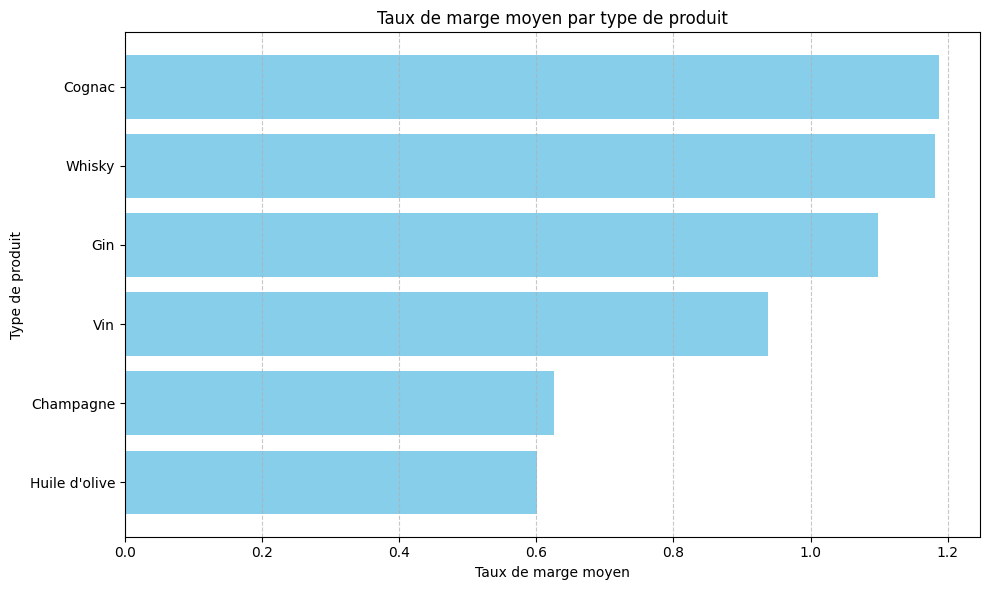

In [ ]:
# Création du DataFrame
df_marge_par_type = Fusion_erp_liaison_web.groupby('product_type')['taux_marge'].mean().reset_index()

# Trier par taux de marge décroissant pour que la plus haute soit en haut
df_marge_par_type = df_marge_par_type.sort_values(by='taux_marge', ascending=False)

# Création du graphique
plt.figure(figsize=(10, 6))
plt.barh(df_marge_par_type['product_type'], df_marge_par_type['taux_marge'], color='skyblue')
plt.xlabel('Taux de marge moyen')
plt.ylabel('Type de produit')
plt.title('Taux de marge moyen par type de produit')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.gca().invert_yaxis()

plt.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

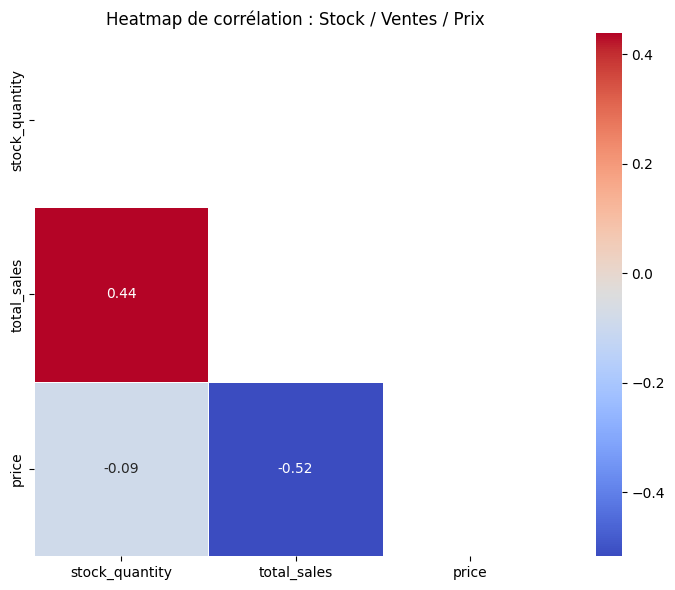

In [ ]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn


corr_data = Fusion_erp_liaison_web[['stock_quantity', 'total_sales', 'price']]
corr_matrix = corr_data.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5, 
            square=True)
plt.title('Heatmap de corrélation : Stock / Ventes / Prix')
plt.tight_layout()
plt.show()


Un stock plus élevé semble favoriser des ventes plus élevées.
Le prix a un impact négatif sur les ventes, ce qui est courant dans le commerce : Les clients acheteraient moins lorsque le prix est élevé

In [ ]:
#Que peut-on conclure des correlations ?

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_merge sur un fichier Excel
# Sauvegarder le DataFrame df_merge dans un fichier Excel
Fusion_erp_liaison_web.to_excel('df_merge_result.xlsx', index=False)

#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.  
